# punto 3



In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
%matplotlib inline

In [3]:
# Cargar dataset y preprocesar (igual que en los notebooks previos)
bank = fetch_ucirepo(id=222)
X = bank.data.features
# Asegurar DataFrame
if not isinstance(X, pd.DataFrame):
    try:
        cols = bank.data.feature_names
    except Exception:
        cols = None
    X = pd.DataFrame(X, columns=cols)
# One-hot encoding
X_enc = pd.get_dummies(X, drop_first=False)
# Eliminar 'duration' si existe para evitar data leakage
if 'duration' in X_enc.columns:
    X_enc = X_enc.drop('duration', axis=1)
# Escalar
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
scaler = StandardScaler()
if len(num_cols) > 0:
    # Asegurarse de escalar solo las columnas numéricas que realmente están en X_enc
    num_cols_to_scale = [c for c in num_cols if c in X_enc.columns]
    if len(num_cols_to_scale) > 0:
        X_enc[num_cols_to_scale] = scaler.fit_transform(X_enc[num_cols_to_scale])
X_scaled = X_enc.values
print('Dataset preprocesado. Shape (n_samples, n_features):', X_scaled.shape)

Dataset preprocesado. Shape (n_samples, n_features): (45211, 46)


### ¿Qué hace esta celda?
Carga el dataset desde UCI, convierte las features a DataFrame si es necesario, aplica one-hot encoding, elimina la columna `duration` para evitar data leakage y escala las columnas numéricas.

- One‑hot encoding convierte categorías en representaciones numéricas que K‑means puede procesar.


In [4]:
# Implementación de J4 (robusta y segura)
def calculate_j4(X, labels):
    """
    Calcula el criterio J4: ratio between_scatter / within_scatter.
    """
    X = np.asarray(X)
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    if n_clusters <= 1:
        return 0.0
    centroids = np.array([X[labels == k].mean(axis=0) for k in unique_labels])
    global_centroid = X.mean(axis=0)
    # within scatter
    within_scatter = 0.0
    for i, k in enumerate(unique_labels):
        cluster_points = X[labels == k]
        if cluster_points.size == 0:
            continue
        diffs = cluster_points - centroids[i]
        within_scatter += np.sum(diffs ** 2)
    # between scatter
    between_scatter = 0.0
    for i, k in enumerate(unique_labels):
        n_k = np.sum(labels == k)
        between_scatter += n_k * np.sum((centroids[i] - global_centroid) ** 2)
    if within_scatter == 0.0:
        return float('inf')
    return between_scatter / within_scatter

### ¿Qué hace esta celda?
Define la función `calculate_j4`, que implementa el criterio J4 (ratio entre la dispersión entre clusters y la dispersión interna). Devuelve un número mayor cuando la separación entre clusters es grande y la dispersión interna es pequeña.

¿Qué se espera lograr?
- Disponer de una métrica que combine separación y cohesión para comparar distintas particiones (diferentes k) en igualdad de condiciones.

¿Por qué se realiza así?
- J4 incorpora explícitamente ambas componentes (between y within), a diferencia de la inercia que solo mide cohesión interna. Esto es útil cuando queremos favorecer soluciones con buena separación entre segmentos además de compactos internamente.

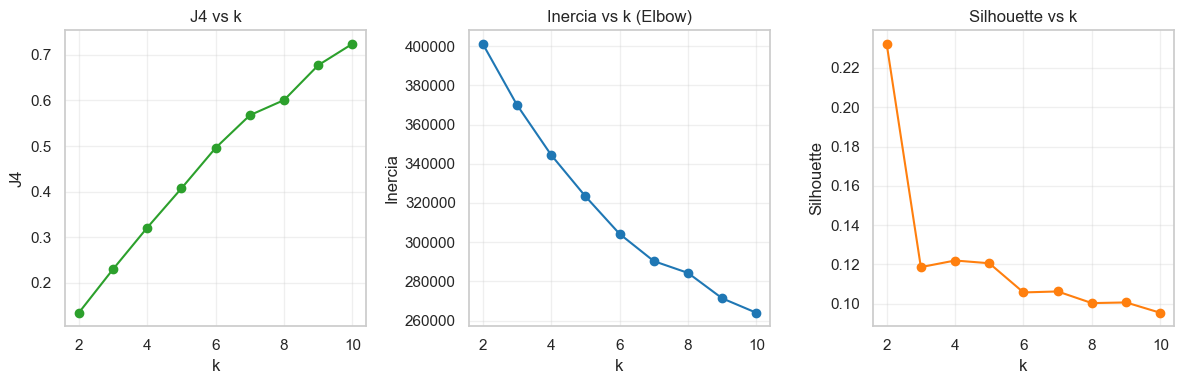

Mejor k según J4: 10  (J4= 0.7242 )


In [5]:
# Buscar el mejor k según J4 en un rango (2..10)
k_range = list(range(2, 11))
j4_scores = []
inertias = []
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    j4 = calculate_j4(X_scaled, labels)
    j4_scores.append(j4)
    inertias.append(km.inertia_)
    try:
        sil = silhouette_score(X_scaled, labels)
    except Exception:
        sil = np.nan
    sil_scores.append(sil)
# Mostrar resultados
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(k_range, j4_scores, '-o', color='tab:green')
plt.xlabel('k')
plt.ylabel('J4')
plt.title('J4 vs k')
plt.grid(alpha=0.3)
plt.subplot(1,3,2)
plt.plot(k_range, inertias, '-o', color='tab:blue')
plt.xlabel('k')
plt.ylabel('Inercia')
plt.title('Inercia vs k (Elbow)')
plt.grid(alpha=0.3)
plt.subplot(1,3,3)
plt.plot(k_range, sil_scores, '-o', color='tab:orange')
plt.xlabel('k')
plt.ylabel('Silhouette')
plt.title('Silhouette vs k')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# Seleccionar mejor k según J4
best_idx = int(np.nanargmax(j4_scores))
best_k = k_range[best_idx]
print('Mejor k según J4:', best_k, ' (J4=', round(j4_scores[best_idx],4),')')

Resultados con k=10: J4=0.7256, Inercia=263733.79, Silhouette=0.0958


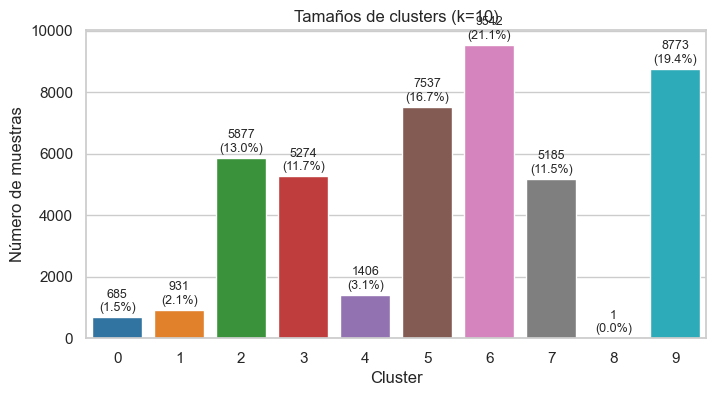

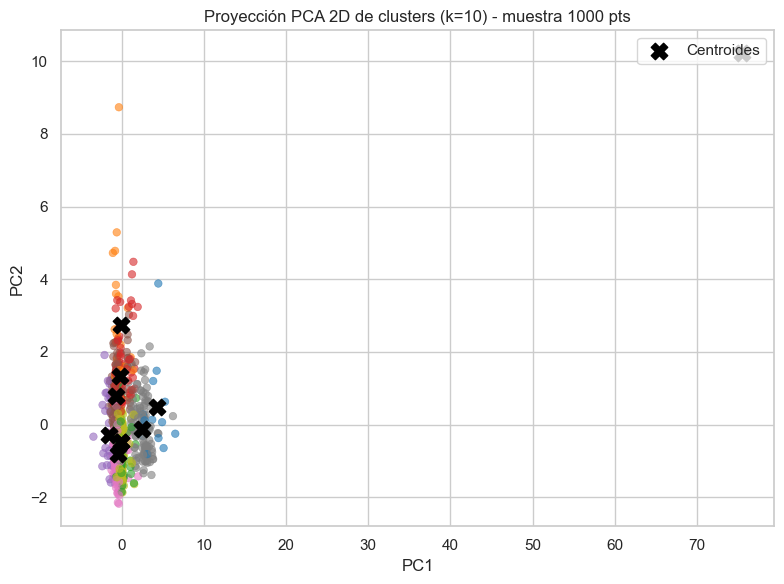

In [7]:
# Ajustar K-means con el mejor k y mostrar métricas finales
km = KMeans(n_clusters=best_k, random_state=42, n_init=20)
labels_best = km.fit_predict(X_scaled)
j4_final = calculate_j4(X_scaled, labels_best)
inertia_final = km.inertia_
sil_final = silhouette_score(X_scaled, labels_best)
print(f'Resultados con k={best_k}: J4={j4_final:.4f}, Inercia={inertia_final:.2f}, Silhouette={sil_final:.4f}')
# Tamaños de cluster
counts = np.bincount(labels_best)
percent = 100.0 * counts / counts.sum()
plt.figure(figsize=(8,4))
ax = sns.barplot(x=list(range(best_k)), y=counts, palette='tab10')
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2.,
        height + max(counts)*0.01,
        f"{int(height)}\n({percent[i]:.1f}%)",
        ha='center', va='bottom', fontsize=9
    )
plt.xlabel('Cluster')
plt.ylabel('Número de muestras')
plt.title(f'Tamaños de clusters (k={best_k})')
plt.show()
# Proyección PCA 2D (submuestreo para claridad)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
plot_n = min(1000, X_pca.shape[0])
rng = np.random.default_rng(42)
plot_idx = rng.choice(X_pca.shape[0], size=plot_n, replace=False)
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[plot_idx,0], y=X_pca[plot_idx,1], hue=labels_best[plot_idx], palette='tab10', s=30, alpha=0.6, edgecolor=None, legend=False)
centroids_pca = pca.transform(km.cluster_centers_)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], c='black', s=140, marker='X', label='Centroides')
plt.title(f'Proyección PCA 2D de clusters (k={best_k}) - muestra {plot_n} pts')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()